In [1]:
# --------------------------------------------------------
# External packages
import jax.numpy as jnp
import matplotlib.pyplot as plt

# --------------------------------------------------------
# KiRATE modules
from KiRATE.kinetics import Threebody

# Three-body Reactions

This notebook demonstrates the use of the `Threebody` class for modeling three-body reactions with third-body efficiencies.

```
O+H+M<=>OH+M                             5.000E+17   -1.000        .00
H2/2.00/ H2O/6.00/ CH4/2.00/ CO/1.50/ CO2/2.00/ C2H6/3.00/ AR/ .70/ 
```

In [2]:
# --------------------------------------------------------
# Construction from a python dictionary
reaction = Threebody(
    name="OH+H+M=OH+M",
    parameters={"A": 5.000e17, "n": -1.000, "Ea": 0.000},
    efficiencies={"H2": 2.000, "H2O": 6.00, "CH4": 2.00, "CO": 1.50, "CO2": 2.00, "C2H6": 3.00, "AR": 0.70},
)

# --------------------------------------------------------
# Construction from a CHEMKIN-fromatted string
reaction = Threebody.from_chemkin(
    """
    O+H+M<=>OH+M                             5.000E+17   -1.000        .00
    H2/2.00/ H2O/6.00/ CH4/2.00/ CO/1.50/ CO2/2.00/ C2H6/3.00/ AR/ .70/
    """
)

# --------------------------------------------------------
# Object inspection
print(f"Representer:\n{repr(reaction)}\n")
print(f"String representation:\n{str(reaction)}")  # This always print the CHEMKIN-formatted string

Representer:
Threebody(
 name = O+H+M<=>OH+M
 A    = 5.00000e+17
 n    = -1.00000e+00
 Ea   = 0.00000e+00
 efficiencies = {
  H2   = 2.00000E+00
  H2O  = 6.00000E+00
  CH4  = 2.00000E+00
  CO   = 1.50000E+00
  CO2  = 2.00000E+00
  C2H6 = 3.00000E+00
  AR   = 7.00000E-01
 }
)

String representation:
O+H+M<=>OH+M		5.00000E+17 -1.00000E+00 0.00000E+00
 H2 / 2.00000E+00 / H2O / 6.00000E+00 / CH4 / 2.00000E+00 / CO / 1.50000E+00 / CO2 / 2.00000E+00 / C2H6 / 3.00000E+00 / AR / 7.00000E-01 /


(300, 10)


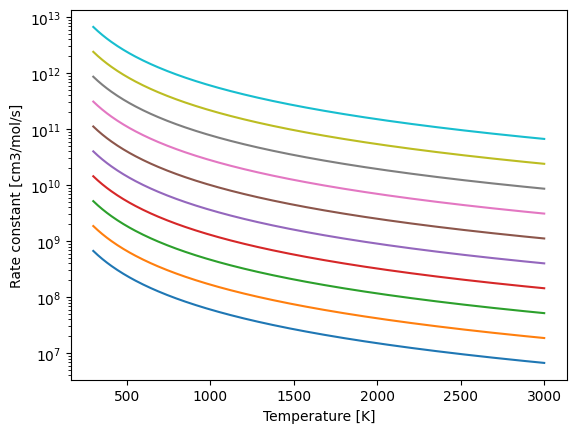

In [6]:
T = jnp.linspace(300, 3000, 300)
P = jnp.logspace(jnp.log10(0.01), jnp.log10(100), 10)

kinetic_constant = reaction.rate_constant(T, P)
h2_kinetic_constant = reaction.rate_constant(T, 1, {"H2O": 1})

print(kinetic_constant.shape)

# --------------------------------------------------------
# Let's visualize it
plt.semilogy(T, kinetic_constant)
# plt.semilogy(T, h2_kinetic_constant)
plt.xlabel("Temperature [K]")
plt.ylabel("Rate constant [cm3/mol/s]")
plt.show()